In [ ]:

import numpy as np
import pandas as pd 



In [2]:
import pandas as pd
import matplotlib.pyplot as plt

metadata_df = pd.read_csv('Metadata_Participants.csv')

print("Metadata Summary:")
print(metadata_df.head())

summary_stats = metadata_df.describe(include='all')
print("\nSummary Statistics:")
print(summary_stats)

categorical_columns = metadata_df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"\nUnique values for '{col}':")
    print(metadata_df[col].value_counts())

Metadata Summary:
   ParticipantID Gender  Age Class  CARS Score
0              1      M  7.0   ASD        32.5
1              2      F  8.9   ASD        36.5
2              3      M  4.4   ASD        27.0
3              4      M  6.9   ASD        35.0
4              5      M  8.9   ASD        31.0

Summary Statistics:
        ParticipantID Gender        Age Class  CARS Score
count       59.000000     59  59.000000    59   29.000000
unique            NaN      2        NaN     2         NaN
top               NaN      M        NaN    TD         NaN
freq              NaN     38        NaN    30         NaN
mean        30.000000    NaN   7.883051   NaN   32.965517
std         17.175564    NaN   2.791252   NaN    6.551896
min          1.000000    NaN   2.700000   NaN   17.000000
25%         15.500000    NaN   5.750000   NaN   27.000000
50%         30.000000    NaN   8.100000   NaN   34.500000
75%         44.500000    NaN   9.800000   NaN   36.500000
max         59.000000    NaN  12.900000  

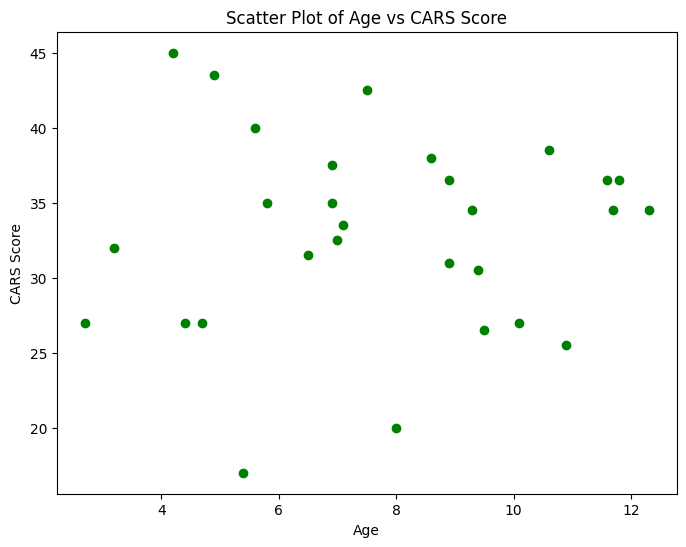

In [3]:
# Scatter plot of Age vs CARS Score
plt.figure(figsize=(8, 6))
plt.scatter(metadata_df['Age'], metadata_df['CARS Score'], color='green')
plt.xlabel('Age')
plt.ylabel('CARS Score')
plt.title('Scatter Plot of Age vs CARS Score')
plt.show()

In [4]:
import os
import pandas as pd

# Correct way
folder_path = 'E:\\Deep Learning\\My_datasets\\autism\\Eye-tracking Output'
file_list = os.listdir(folder_path)


data_frames = []


for file_name in file_list:
    if file_name.endswith('.csv'):
        file_path = os.path.join(folder_path, file_name)
        df = pd.read_csv(file_path)
        data_frames.append(df)

combined_df = pd.concat(data_frames, ignore_index=True)






C:\Users\zulqa\AppData\Local\Temp\ipykernel_19532\2028629382.py:15: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\zulqa\AppData\Local\Temp\ipykernel_19532\2028629382.py:15: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\zulqa\AppData\Local\Temp\ipykernel_19532\2028629382.py:15: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\zulqa\AppData\Local\Temp\ipykernel_19532\2028629382.py:15: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\zulqa\AppData\Local\Temp\ipykernel_19532\2028629382.py:15: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\z

In [5]:
print(combined_df.head())
summary_stats = combined_df.describe()
print("\nSummary Statistics:")
print(summary_stats)

   Unnamed: 0  RecordingTime [ms] Time of Day [h:m:s:ms]     Trial  \
0           0         4780015.315           13:22:17:254  Trial020   
1           1         4780020.865           13:22:17:260  Trial020   
2           2         4780040.758           13:22:17:279  Trial020   
3           3         4780080.503           13:22:17:319  Trial020   
4           4         4780120.360           13:22:17:359  Trial020   

                              Stimulus  Export Start Trial Time [ms]  \
0  20 eye tracking (ballon droite).avi                           0.0   
1  20 eye tracking (ballon droite).avi                           0.0   
2  20 eye tracking (ballon droite).avi                           0.0   
3  20 eye tracking (ballon droite).avi                           0.0   
4  20 eye tracking (ballon droite).avi                           0.0   

   Export End Trial Time [ms] Participant  Color  Tracking Ratio [%]  ...  \
0                   52058.676          50  Coral             78.5652 

In [6]:
#We need to filter the data for ASD, Neurotypical, and Unidentified(Pos) participants
# we also have to specify columns of interest - which would be the point of regard and position
asd_df = combined_df[combined_df['Participant'].isin(range(1, 30))]
neurotypical_df = combined_df[combined_df['Participant'].isin(range(30, 60))]
unidentified_df = combined_df[combined_df['Participant'] == 'Unidentified(Pos)']


columns_of_interest = [
    'Eye Position Right X [mm]', 'Eye Position Right Y [mm]', 'Eye Position Right Z [mm]',
    'Eye Position Left X [mm]', 'Eye Position Left Y [mm]', 'Eye Position Left Z [mm]',
    'Pupil Position Right X [px]', 'Pupil Position Right Y [px]',
    'Pupil Position Left X [px]', 'Pupil Position Left Y [px]',
    'Point of Regard Right X [px]', 'Point of Regard Right Y [px]',
    'Point of Regard Left X [px]', 'Point of Regard Left Y [px]'
]

# Calculate the statistics for each group and each column becuz this is important
asd_statistics = asd_df[columns_of_interest].describe()
neurotypical_statistics = neurotypical_df[columns_of_interest].describe()
unidentified_statistics = unidentified_df[columns_of_interest].describe()


print("ASD Group Statistics:")
print(asd_statistics)

print("\nNeurotypical Group Statistics:")
print(neurotypical_statistics)

print("\nUnidentified(Pos) Group Statistics:")
print(unidentified_statistics)

ASD Group Statistics:
       Eye Position Right X [mm] Eye Position Right Y [mm]  \
count                     140735                    140735   
unique                     65501                     64115   
top                       0.0000                    0.0000   
freq                       24824                     24824   

       Eye Position Right Z [mm] Eye Position Left X [mm]  \
count                     140735                   134547   
unique                     65930                    61809   
top                       0.0000                   0.0000   
freq                       24824                    23095   

       Eye Position Left Y [mm] Eye Position Left Z [mm]  \
count                    134547                   134547   
unique                    60535                    62082   
top                      0.0000                   0.0000   
freq                      23095                    23095   

       Pupil Position Right X [px] Pupil Position Right Y [p

In [7]:
# Check for missing values in the new columns of interest
missing_values = combined_df[columns_of_interest].isnull().sum()

print("Missing values in the new columns of interest:")
print(missing_values)


Missing values in the new columns of interest:
Eye Position Right X [mm]       260074
Eye Position Right Y [mm]       260074
Eye Position Right Z [mm]       260074
Eye Position Left X [mm]        396306
Eye Position Left Y [mm]        396306
Eye Position Left Z [mm]        396306
Pupil Position Right X [px]     260074
Pupil Position Right Y [px]     260074
Pupil Position Left X [px]      396306
Pupil Position Left Y [px]      396306
Point of Regard Right X [px]         0
Point of Regard Right Y [px]         0
Point of Regard Left X [px]     136232
Point of Regard Left Y [px]     136232
dtype: int64


In [8]:
# Convert non-numeric values to NaN
for column in columns_of_interest:
    combined_df[column] = pd.to_numeric(combined_df[column], errors='coerce')

# Fill missing numerical values with the mean
for column in columns_of_interest:
    if combined_df[column].dtype != 'object':  # Check if the column is numerical
        combined_df[column].fillna(combined_df[column].mean(), inplace=True)

# Check again for missing values
missing_values_after = combined_df[columns_of_interest].isnull().sum()

print("Missing values after filling:")
print(missing_values_after)

     

C:\Users\zulqa\AppData\Local\Temp\ipykernel_19532\1297359331.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df[column].fillna(combined_df[column].mean(), inplace=True)


Missing values after filling:
Eye Position Right X [mm]       0
Eye Position Right Y [mm]       0
Eye Position Right Z [mm]       0
Eye Position Left X [mm]        0
Eye Position Left Y [mm]        0
Eye Position Left Z [mm]        0
Pupil Position Right X [px]     0
Pupil Position Right Y [px]     0
Pupil Position Left X [px]      0
Pupil Position Left Y [px]      0
Point of Regard Right X [px]    0
Point of Regard Right Y [px]    0
Point of Regard Left X [px]     0
Point of Regard Left Y [px]     0
dtype: int64


In [9]:
# Display the first few rows of the filled columns
print(combined_df[columns_of_interest].head())


   Eye Position Right X [mm]  Eye Position Right Y [mm]  \
0                  -3.341673                 -19.729795   
1                  -3.341673                 -19.729795   
2                  -3.341673                 -19.729795   
3                  -3.341673                 -19.729795   
4                  -3.341673                 -19.729795   

   Eye Position Right Z [mm]  Eye Position Left X [mm]  \
0                  496.92896                 -9.993076   
1                  496.92896                 -9.993076   
2                  496.92896                 -9.993076   
3                  496.92896                 -9.993076   
4                  496.92896                 -9.993076   

   Eye Position Left Y [mm]  Eye Position Left Z [mm]  \
0                -19.580494                492.986374   
1                -19.580494                492.986374   
2                -19.580494                492.986374   
3                -19.580494                492.986374   
4          

In [10]:
def map_category(participant):
    if isinstance(participant, tuple):
        participant = participant[1]  # Extract the second element of the tuple
    if isinstance(participant, str) and participant.startswith('Unidentified'):
        return 'Other'
    elif isinstance(participant, int):
        if 1 <= participant <= 29:
            return 'ASD'
        elif 30 <= participant <= 59:
            return 'Neurotypical'
    return 'Other'

combined_df['Participant Group'] = combined_df['Participant'].map(map_category)

print(combined_df['Participant Group'].value_counts())

Participant Group
Other           1839451
Neurotypical     225675
ASD              187817
Name: count, dtype: int64


In [11]:
print(map_category(1))  # Should output 'ASD'
print(map_category(30))  # Should output 'Neurotypical'
print(map_category('Unidentified(Pos)'))  # Should output 'Other'

ASD
Neurotypical
Other


In [12]:
from scipy.stats import f_oneway

# Filter the data for 'ASD' and 'Neurotypical' categories
asd_td_df = combined_df[(combined_df['Participant Group'] == 'ASD') | (combined_df['Participant Group'] == 'Neurotypical')]

# Create a loop to calculate ANOVA for each column of interest
p_values = {}
for column in columns_of_interest:
    f_statistic, p_value = f_oneway(
        asd_td_df[asd_td_df['Participant Group'] == 'ASD'][column],
        asd_td_df[asd_td_df['Participant Group'] == 'Neurotypical'][column]
    )
    print(f"ANOVA for {column}: F-statistic = {f_statistic}, p-value = {p_value}")
    p_values[column] = p_value


ANOVA for Eye Position Right X [mm]: F-statistic = 12394.083609795221, p-value = 0.0
ANOVA for Eye Position Right Y [mm]: F-statistic = 12233.289424301624, p-value = 0.0
ANOVA for Eye Position Right Z [mm]: F-statistic = 26887.881637611597, p-value = 0.0
ANOVA for Eye Position Left X [mm]: F-statistic = 11496.90442197347, p-value = 0.0
ANOVA for Eye Position Left Y [mm]: F-statistic = 23565.893218201043, p-value = 0.0
ANOVA for Eye Position Left Z [mm]: F-statistic = 21606.284782739527, p-value = 0.0
ANOVA for Pupil Position Right X [px]: F-statistic = 6857.4716334090235, p-value = 0.0
ANOVA for Pupil Position Right Y [px]: F-statistic = 5106.69787186621, p-value = 0.0
ANOVA for Pupil Position Left X [px]: F-statistic = 7136.206573445905, p-value = 0.0
ANOVA for Pupil Position Left Y [px]: F-statistic = 1600.1798920602641, p-value = 0.0
ANOVA for Point of Regard Right X [px]: F-statistic = 35737.83540762197, p-value = 0.0
ANOVA for Point of Regard Right Y [px]: F-statistic = 28073.4935

In [27]:
combined_df.shape

(2252943, 60)

In [26]:
asd_td_df.shape

(413492, 60)

ANOVA for Eye Position Right X [mm]: F-statistic = 12394.083609795221, p-value = 0.0
ANOVA for Eye Position Right Y [mm]: F-statistic = 12233.289424301624, p-value = 0.0
ANOVA for Eye Position Right Z [mm]: F-statistic = 26887.881637611597, p-value = 0.0
ANOVA for Eye Position Left X [mm]: F-statistic = 11496.90442197347, p-value = 0.0
ANOVA for Eye Position Left Y [mm]: F-statistic = 23565.893218201043, p-value = 0.0
ANOVA for Eye Position Left Z [mm]: F-statistic = 21606.284782739527, p-value = 0.0
ANOVA for Pupil Position Right X [px]: F-statistic = 6857.4716334090235, p-value = 0.0
ANOVA for Pupil Position Right Y [px]: F-statistic = 5106.69787186621, p-value = 0.0
ANOVA for Pupil Position Left X [px]: F-statistic = 7136.206573445905, p-value = 0.0
ANOVA for Pupil Position Left Y [px]: F-statistic = 1600.1798920602641, p-value = 0.0
ANOVA for Point of Regard Right X [px]: F-statistic = 35737.83540762197, p-value = 0.0
ANOVA for Point of Regard Right Y [px]: F-statistic = 28073.4935

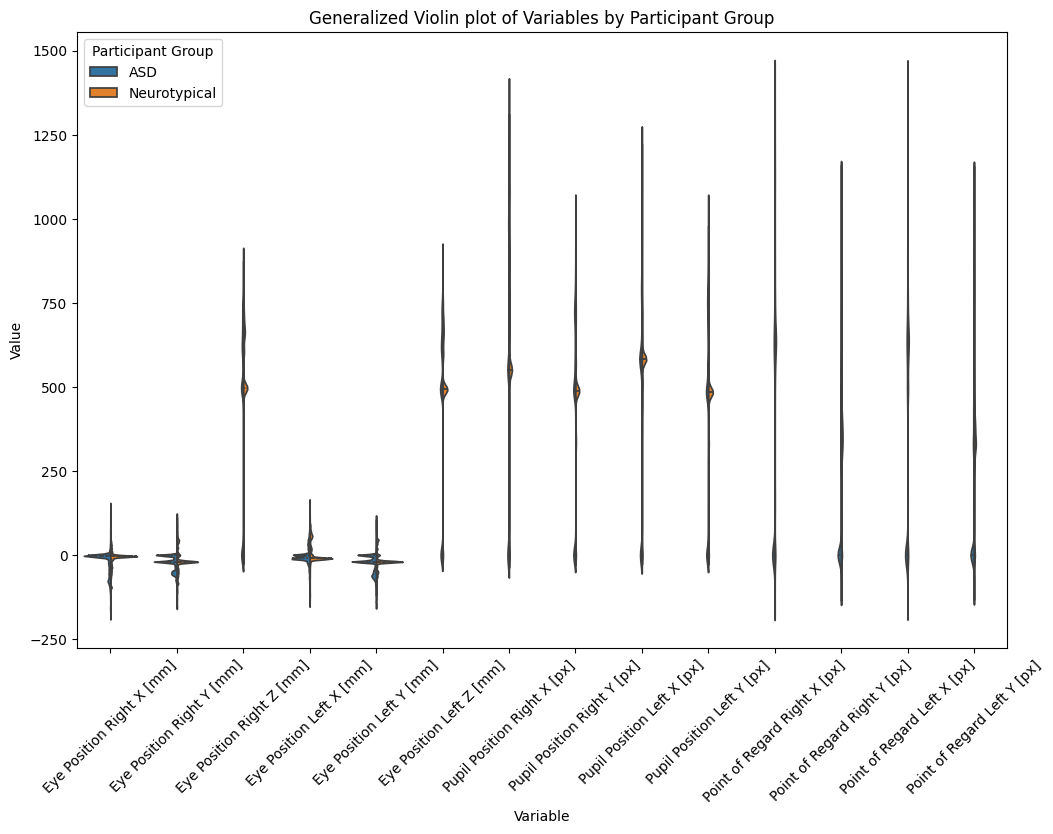

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
import pandas as pd

# Filter the data for 'ASD' and 'Neurotypical' categories
asd_td_df = combined_df[(combined_df['Participant Group'] == 'ASD') | (combined_df['Participant Group'] == 'Neurotypical')]

# Create a loop to calculate ANOVA for each column of interest
p_values = {}
for column in columns_of_interest:
    f_statistic, p_value = f_oneway(
        asd_td_df[asd_td_df['Participant Group'] == 'ASD'][column],
        asd_td_df[asd_td_df['Participant Group'] == 'Neurotypical'][column]
    )
    print(f"ANOVA for {column}: F-statistic = {f_statistic}, p-value = {p_value}")
    p_values[column] = p_value

# Combine the data for both groups
combined_data = pd.melt(asd_td_df, id_vars='Participant Group', value_vars=columns_of_interest, var_name='Variable', value_name='Value')

# Visualize the data
plt.figure(figsize=(12, 8))
sns.violinplot(x='Variable', y='Value', hue='Participant Group', data=combined_data, split=True, inner='quart')
plt.title("Generalized Violin plot of Variables by Participant Group")
plt.xticks(rotation=45)
plt.show()

In [14]:
########PRE-PROCESSING PORTION OF THE NOTEBOOK ###################
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

# Filter the data for ASD, Neurotypical, and Unidentified(Pos) participants
# & Combine the filtered dataframes later
asd_df = combined_df[combined_df['Participant'].isin(range(1, 30))]
neurotypical_df = combined_df[combined_df['Participant'].isin(range(30, 60))]
unidentified_df = combined_df[combined_df['Participant'] == 'Unidentified(Pos)']


combined_data = pd.concat([asd_df, neurotypical_df])

# Define the columns of interest
columns_of_interest = [
    'Eye Position Right X [mm]', 'Eye Position Right Y [mm]', 'Eye Position Right Z [mm]',
    'Eye Position Left X [mm]', 'Eye Position Left Y [mm]', 'Eye Position Left Z [mm]',
    'Pupil Position Right X [px]', 'Pupil Position Right Y [px]',
    'Pupil Position Left X [px]', 'Pupil Position Left Y [px]',
    'Point of Regard Right X [px]', 'Point of Regard Right Y [px]',
    'Point of Regard Left X [px]', 'Point of Regard Left Y [px]',
    'Participant Group'
]

# Select only the columns of interest for analysis
combined_data = combined_data[columns_of_interest]

# Separate features (X) and target (y)
X = combined_data.drop('Participant Group', axis=1)
y = combined_data['Participant Group']

# Normalize the features -- YA NEED TO NORMALIZE IT
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Encode the target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

X_train shape: (330793, 14), y_train shape: (330793,)
X_val shape: (82699, 14), y_val shape: (82699,)


In [16]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Combine y_train and y_val to ensure all labels are accounted for
y_combined = np.concatenate((y_train, y_val), axis=0)

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit LabelEncoder to y_combined
label_encoder.fit(y_combined)

# Check the mapping of numeric labels to original labels
print("Mapping of numeric labels to original labels:")
for numeric_label in np.unique(y_combined):
    original_label = label_encoder.inverse_transform([numeric_label])[0]
    print(f"Numeric Label: {numeric_label}, Original Label: {original_label}")

# Transform y_train and y_val to encoded labels
y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)

# Check the number of classes
num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

Mapping of numeric labels to original labels:
Numeric Label: 0, Original Label: 0
Numeric Label: 1, Original Label: 1
Number of classes: 2


In [17]:
# Check the distribution of classes because i know for a damn fact its imbalanced a.f
class_counts = combined_df['Participant Group'].value_counts()
print("Class Distribution:")
print(class_counts)
     

Class Distribution:
Participant Group
Other           1839451
Neurotypical     225675
ASD              187817
Name: count, dtype: int64


In [18]:
from imblearn.over_sampling import RandomOverSampler

# Define oversampling strategy
oversample = RandomOverSampler(sampling_strategy='minority')

# Fit and apply the oversampling strategy
X_train_balanced, y_train_balanced = oversample.fit_resample(X_train, y_train)


In [19]:
import numpy as np

# Combine y_train_balanced and y_val to ensure all labels are accounted for
y_combined_balanced = np.concatenate((y_train_balanced, y_val), axis=0)

# Print the class distribution
class_counts_balanced = np.bincount(y_combined_balanced)
print("Balanced Class Distribution:")
for i, count in enumerate(class_counts_balanced):
    print(f"Class {i}: {count} samples")

Balanced Class Distribution:
Class 0: 218024 samples
Class 1: 225675 samples


In [20]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback, EarlyStopping
import matplotlib.pyplot as plt

# Define the columns of interest
columns_of_interest = [
    'Eye Position Right X [mm]', 'Eye Position Right Y [mm]', 'Eye Position Right Z [mm]',
    'Eye Position Left X [mm]', 'Eye Position Left Y [mm]', 'Eye Position Left Z [mm]',
    'Pupil Position Right X [px]', 'Pupil Position Right Y [px]',
    'Pupil Position Left X [px]', 'Pupil Position Left Y [px]',
    'Point of Regard Right X [px]', 'Point of Regard Right Y [px]',
    'Point of Regard Left X [px]', 'Point of Regard Left Y [px]',
    'Participant Group'
]



In [21]:
# Filter the data for 'ASD' and 'TD' categories
asd_td_df = combined_df[(combined_df['Participant Group'] == 'ASD') | (combined_df['Participant Group'] == 'Neurotypical')][columns_of_interest]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(asd_td_df.drop('Participant Group', axis=1))

# Split the data into features (X) and labels (y)
X = scaled_data
y = asd_td_df['Participant Group']

# Encode labels for 'ASD' and 'TD' categories only
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [51]:
X.shape

(413492, 14)

In [22]:

X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Define the Sequential model
#ReLu f(x) = max(0, x)
model = Sequential([
    # X_train.shape[1] is the number of features in your input data (14 features into the first hidden layer)
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(2, activation='softmax')  # 2 output units for 'ASD' and 'TD' categories
])

model.summary()

e:\Deep Learning\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,306 (40.26 KB)

 Trainable params: 10,306 (40.26 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Define early stopping callback
early_stopping = EarlyStopping(patience=3, restore_best_weights=True)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model with early stopping callback
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), callbacks=[ early_stopping])



Epoch 1/50
10338/10338 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.8295 - loss: 0.3846 - val_accuracy: 0.8618 - val_loss: 0.3197
Epoch 2/50
10338/10338 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8554 - loss: 0.3301 - val_accuracy: 0.8649 - val_loss: 0.3041
Epoch 3/50
10338/10338 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8600 - loss: 0.3182 - val_accuracy: 0.8671 - val_loss: 0.2990
Epoch 4/50
10338/10338 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8622 - loss: 0.3120 - val_accuracy: 0.8701 - val_loss: 0.2948
Epoch 5/50
10338/10338 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.8637 - loss: 0.3087 - val_accuracy: 0.8693 - val_loss: 0.2974
Epoch 6/50
10338/10338 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8650 - loss: 0.3056 - val_accuracy: 0.8726 - val_loss: 0.2875
Epoch 7/50
10338/10338 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - accuracy: 0.8658 - loss: 0.3037 - val_accuracy: 0.8726 - val_loss: 0.2855
Epoch 8/50
10338/10338 ━━━━━━━━━━━━━━━━━━━━ 101s 10ms/step - accuracy

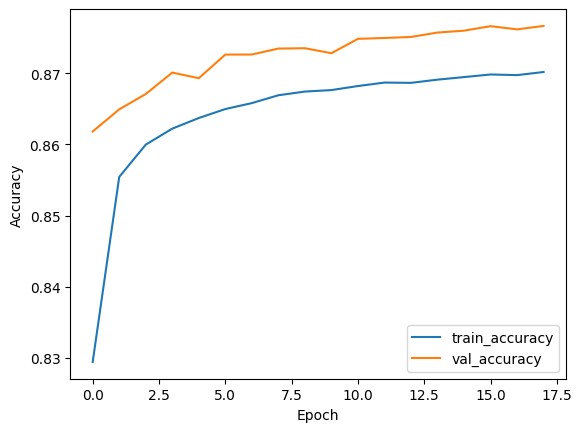

In [24]:

# Visualize training history
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [25]:
from sklearn.metrics import classification_report, roc_auc_score


y_pred_prob = model.predict(X_val)
y_pred = y_pred_prob.argmax(axis=-1)

y_val_decoded = label_encoder.inverse_transform(y_val)
y_pred_decoded = label_encoder.inverse_transform(y_pred)

# Print classification report
print("Classification Report:")
print(classification_report(y_val_decoded, y_pred_decoded))

# Calculate and print AUC
y_pred_prob = model.predict(X_val)[:, 0]  # Probability of 'ASD' class
auc = roc_auc_score(y_val, y_pred_prob)
print(f"AUC: {auc:.4f}")


2585/2585 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Classification Report:
              precision    recall  f1-score   support

         ASD       0.87      0.85      0.86     37357
Neurotypical       0.88      0.89      0.89     45342

    accuracy                           0.88     82699
   macro avg       0.88      0.87      0.87     82699
weighted avg       0.88      0.88      0.88     82699

2585/2585 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
AUC: 0.0518


In [ ]:
import joblib

# Run this in the environment where you trained the model
# 1. Save the Keras model
model.save('autism_model.h5')

# 2. Save the Scaler (This is what you used in Cell 21)
joblib.dump(scaler, 'scaler.pkl')

# 3. Save the Label Encoder (This is what you used in Cell 21)
joblib.dump(label_encoder, 'label_encoder.pkl')

print("Files generated: autism_model.h5, scaler.pkl, label_encoder.pkl")

Files generated: autism_model.h5, scaler.pkl, label_encoder.pkl


: 